In [1]:
import os
import glob
import re
from datetime import timedelta, datetime

import hist
import uproot

import dask
import awkward as ak
import dask_awkward as da
import dask.dataframe as dd
import dask_histogram as dh
from dask.diagnostics import ProgressBar

import boost_histogram as bh

from particle import Particle, ParticleNotFound

import numpy as np
from tqdm import tqdm
import matplotlib as mpl
import matplotlib.pyplot as plt

import pandas as pd


import time

import plotly.graph_objects as go


***
# Loading using dask

In [2]:
data_path = "/home/b/bkoberg/AGW_LowRad/"
path_Version = "home"
path_Material = "bkoberg"
path_length = "XeSim"


min_data_file_size = 5 * 1024 * 1024
data_files = glob.glob(f"{data_path}/{path_Version}/{path_Material}/{path_length}/*.root")
print(f"Found {len(data_files)} files matching pattern '{path_length}' in '{data_path}/{path_Version}/{path_Material}/{path_length}/'.")

uproot_files = [{f:"events/events"} for f in data_files if os.path.getsize(f) > min_data_file_size]
print(f"Available keys in uproot files: {uproot.open(uproot_files[0]).keys()}")

Found 2 files matching pattern 'XeSim' in '/home/b/bkoberg/AGW_LowRad//home/bkoberg/XeSim/'.
Available keys in uproot files: ['eventid', 'type_pri', 'type_pri_id', 'e_pri', 'xp_pri', 'yp_pri', 'zp_pri', 'cx_pri', 'cy_pri', 'cz_pri', 'vol_pri', 'vol_pri_hash', 'NSave', 'Save_flag', 'Save_desc', 'Save_type', 'Save_x', 'Save_y', 'Save_z', 'Save_cx', 'Save_cy', 'Save_cz', 'Save_e', 'Save_t', 'Save_eventid', 'Save_trackid', 'Save_volume', 'NNAct', 'NAct_eventid', 'NAct_trackid', 'NAct_parentid', 'NAct_t', 'NAct_volume', 'NAct_volume_hash', 'NAct_x', 'NAct_y', 'NAct_z', 'NAct_process_name', 'NAct_process_category', 'NAct_process_ID', 'NAct_particle_name', 'NAct_particle_lifetime', 'NAct_particle_id', 'NAct_particle_atomicnumber', 'NAct_particle_mass', 'NAct_particle_excitationEnergy']


In [3]:
pictures_path = '/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures'
if not os.path.exists(f'{pictures_path}/{path_Version}/{path_Material}/{path_length}'):
    os.makedirs(f'{pictures_path}/{path_Version}/{path_Material}/{path_length}')

## Meta-Daten und Tabellen für IDs

In [4]:
file = data_files[0]  # Use the first file for demonstration
rfile = uproot.open(file)

print(f"The file contains {len(rfile.keys())} keys:")
for key in rfile.keys():
    print(f"  {key}")

print(f"\nExecuted with G4VERSION {rfile['G4VERSION_TAG'].member('fTitle')}")
print(f"Total runtime: {rfile['G4RUNTIME'].member('fVal')} seconds")
print(f"Number of events: {rfile['events/nbevents'].member('fVal')}")

print(f"\nUsing the macros:")
for macro in rfile["macros"].keys():
    print(f"--> {rfile['macros'][macro].member('fName')}")
    print(f"    File content hidden for brevity ...")
    for line in rfile["macros"][macro].member('fTitle').splitlines():
        print(f"    {line}")
    print("")

The file contains 23 keys:
  G4VERSION_TAG;1
  MC_TAG;1
  MCVERSION_TAG;1
  macros;1
  macros/preinit.mac;1
  macros/det_setup.mac;1
  macros/src_neutron.mac;1
  tables;1
  tables/neutronXS_G4_AIR;1
  tables/neutronXS_G4_WATER;1
  tables/neutronXS_G4_Galactic;1
  tables/neutronXS_LXe;1
  tables/neutronXS_LXe_nA;1
  tables/neutronXS_Rock;1
  tables/neutronXS_Concrete;1
  tables/neutronXS_SS304LSteel;1
  tables/process_subtypes;1
  tables/logical_volumes;1
  tables/physical_volumes;1
  events;1
  events/nbevents;1
  events/events;1
  G4RUNTIME;1

Executed with G4VERSION $Name: geant4-11-00 $
Total runtime: 11932.306722995 seconds
Number of events: 1000000

Using the macros:
--> preinit.mac
    File content hidden for brevity ...
    # ./macros/EnergyDistributionRock/preinit.mac
    
    /control/verbose 0
    /run/verbose 0
    /event/verbose 0
    /tracking/verbose 0
    
    # select how would you like to simulate radioactive decays
    # setting 0 means that you would like to simulate

In [5]:
rfile = uproot.open(file)

physical_volumes = {}
for k,v in zip(*rfile["tables/physical_volumes"].arrays(library="np", how=list)):
    physical_volumes = {**physical_volumes, **{k: v for k, v in zip(k, v)}}

def get_volume_name(volume_id):
    """Get the volume name from the volume ID."""
    _hashes = {v:k for k,v in physical_volumes.items()}
    if volume_id in _hashes:
        return _hashes[volume_id]
    else:
        return f"Unknown volume ID {volume_id}"

subtypes_table = rfile["tables/process_subtypes"].arrays(library="np")

particle_ids = {}
for k,v in zip(subtypes_table['particle_id'], subtypes_table['particle_name']):
    particle_ids = {**particle_ids, **{k: v for k, v in zip(k, v)}}

def get_particle_name(particle_id):
    """Get the particle name from the particle PDG code."""
    if particle_id in particle_ids:
        return particle_ids[particle_id]
    else:
        try:
            try:
                particle = Particle.from_pdgid(particle_id)
                return particle.name
            except ParticleNotFound:
                # Check if nucleus
                if (str(particle_id)[0:2] == "10"):
                    # Remove isomeric state
                    _particle_id = int(str(particle_id)[:9] + "0")
                    particle = Particle.from_pdgid(_particle_id)
                    return particle.name+f"({str(particle_id)[9:]})"
                raise
        except Exception as e:
            return f"Unknown particle code {particle_id}"

process_subtype = {}
for k,v in zip(subtypes_table['process_subtype'], subtypes_table['process_name']):
    process_subtype = {**process_subtype, **{k: v for k, v in zip(k, v)}}

def get_process_name(process_id):
    """Get the process name from the process ID."""
    if process_id in process_subtype:
        return process_subtype[process_id]
    else:
        return f"Unknown process ID {process_id}"

In [6]:
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
        "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22"]
edge_colors = ["#0d3b66", "#b4440e", "#1e6823", "#7c0e1e", "#5e3a8a",
        "#5d4037", "#b21d7c", "#4d4d4d", "#878d32"]

In [7]:
processes = ['conv', 'nCapture', 'RadioactiveDecayBase', 'xi0Inelastic', 'hadElastic']
volumes = ['Absorber', 'LXe','LXeContainer', ]
colors_process = {p: colors[i] for i, p in enumerate(processes)}
colors_Volumes = {v: edge_colors[i] for i, v in enumerate(volumes)}
colors_edges = {v: edge_colors[i] for i, v in enumerate(volumes)}

## Positions

### 2D

In [13]:
da_positions = uproot.dask(uproot_files, filter_name=['xp_pri', 'yp_pri', 'zp_pri','type_pri_id', 'vol_pri','NAct_volume', 'NAct_x', 'NAct_y', 'NAct_z','Save_x', 'Save_y', 'Save_z', 'Save_volume', 'Save_desc'], allow_missing=True, step_size="8GB")
da_positions['type_pri_id'] = ak.flatten(da_positions['type_pri_id'])
da_positions = da_positions[da_positions['type_pri_id'] == 2112]

df_pri = da.to_dataframe(da_positions[['xp_pri', 'yp_pri', 'zp_pri']])
df_NAct = da.to_dataframe(da_positions[[ 'NAct_x', 'NAct_y', 'NAct_z', 'NAct_volume']])
df_Save = da.to_dataframe(da_positions[['Save_x', 'Save_y', 'Save_z', 'Save_volume', 'Save_desc']])


In [14]:
border = 0.1
ranges = []
dfs = [df_pri, df_NAct, df_Save]
coords = [['xp_pri', 'yp_pri', 'zp_pri'], ['NAct_x', 'NAct_y', 'NAct_z'], ['Save_x', 'Save_y', 'Save_z']]

ranges = [[
    (-3000, 3000),  # xp_pri
    (-3000, 3000),  # yp_pri
    (-3000, 3000)],     # zp_pri
    [(-3000, 3000),  # xp_pri
    (-3000, 3000),  # yp_pri
    (-3000, 3000)],      # NAct_z
    [(-3000, 3000),  # xp_pri
    (-3000, 3000),  # yp_pri
    (-3000, 3000)]      # Save_z
]


""" maximum = [ranges[j][1][1]-ranges[j][1][0] for j in range(len(ranges))]
maximum_bins = 300
bins_all = [[(ranges[j][i][1]-ranges[j][i][0]) / maximum[j] * maximum_bins 
             for i in range(len(ranges[j]))] 
             for j in range(len(ranges))]

bins_all[2] = [100, 100, 100] """

#bins_all = [[50, 50, 50], [50, 50, 50], [50, 50, 50]]
bins_all = [[100, 100, 100], [100, 100, 100], [100, 100, 100]]

In [15]:

h3d_computed = []
for i, coord in enumerate(coords):
    bins = [int(b) for b in bins_all[i]]
    h3d = dh.histogramdd([dfs[i][coord[0]], dfs[i][coord[1]], dfs[i][coord[2]]], bins=bins, range=ranges[i], histogram=True)
    with ProgressBar():
        h3d_computed.append(h3d.compute())

[########################################] | 100% Completed | 8.86 ss
[########################################] | 100% Completed | 33.00 s
[########################################] | 100% Completed | 5.38 sms


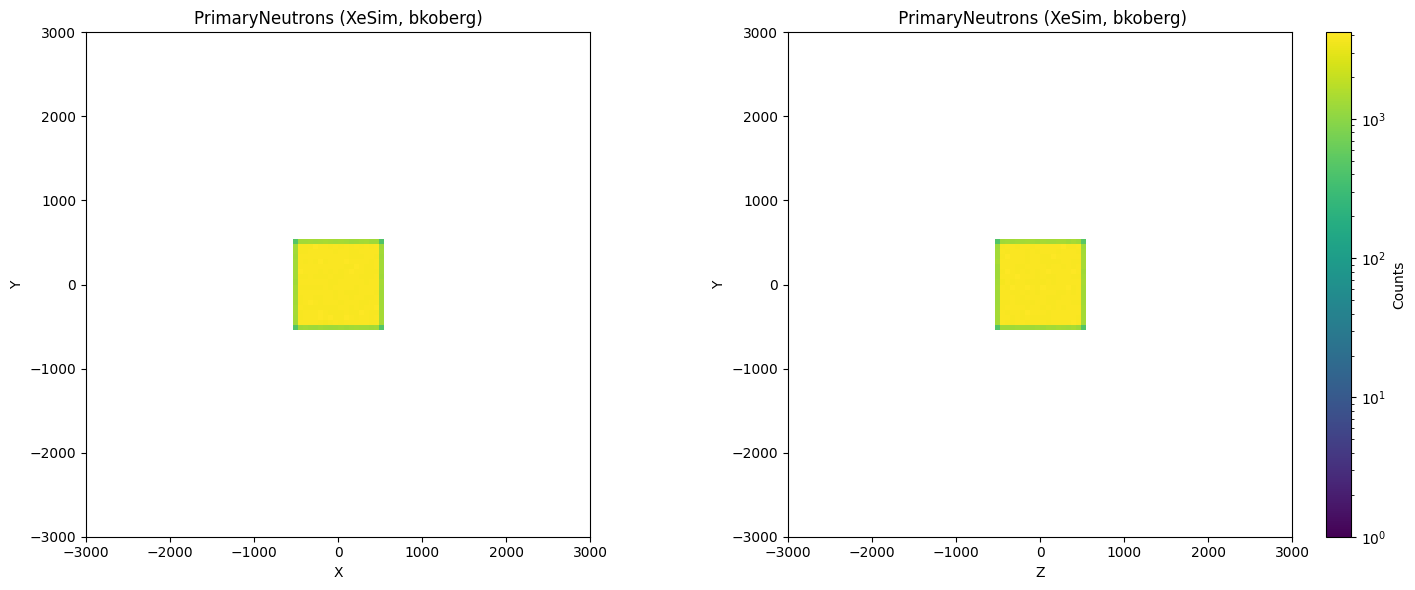

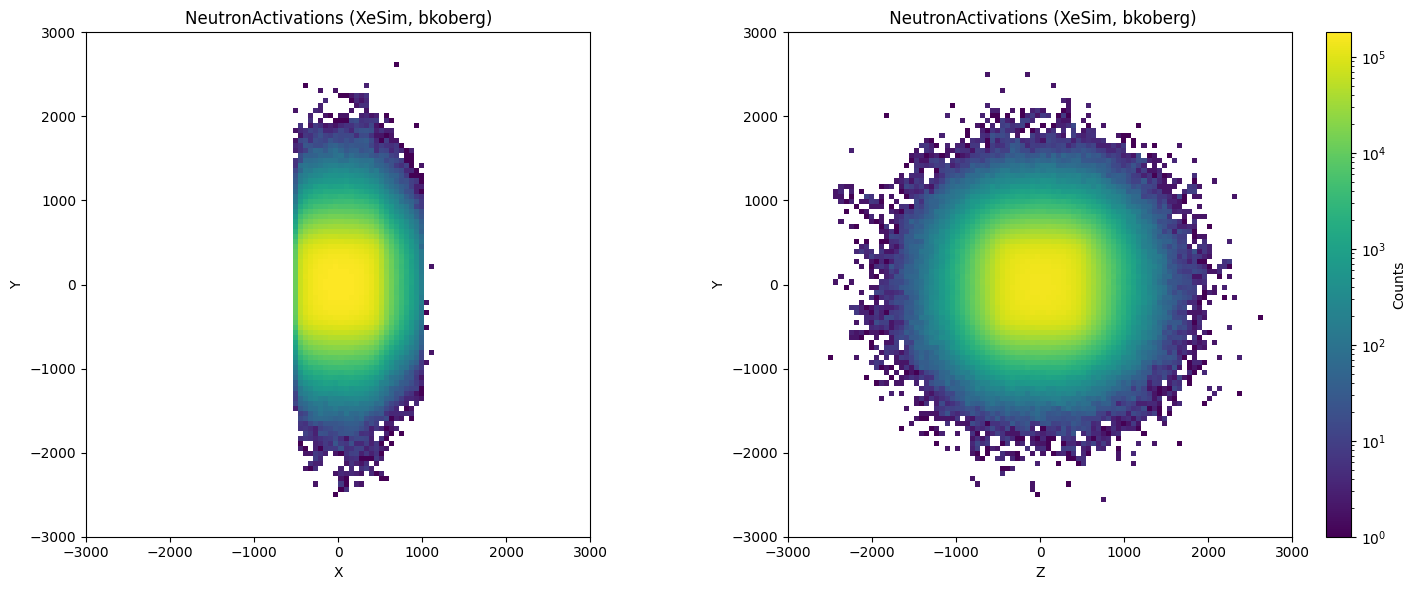

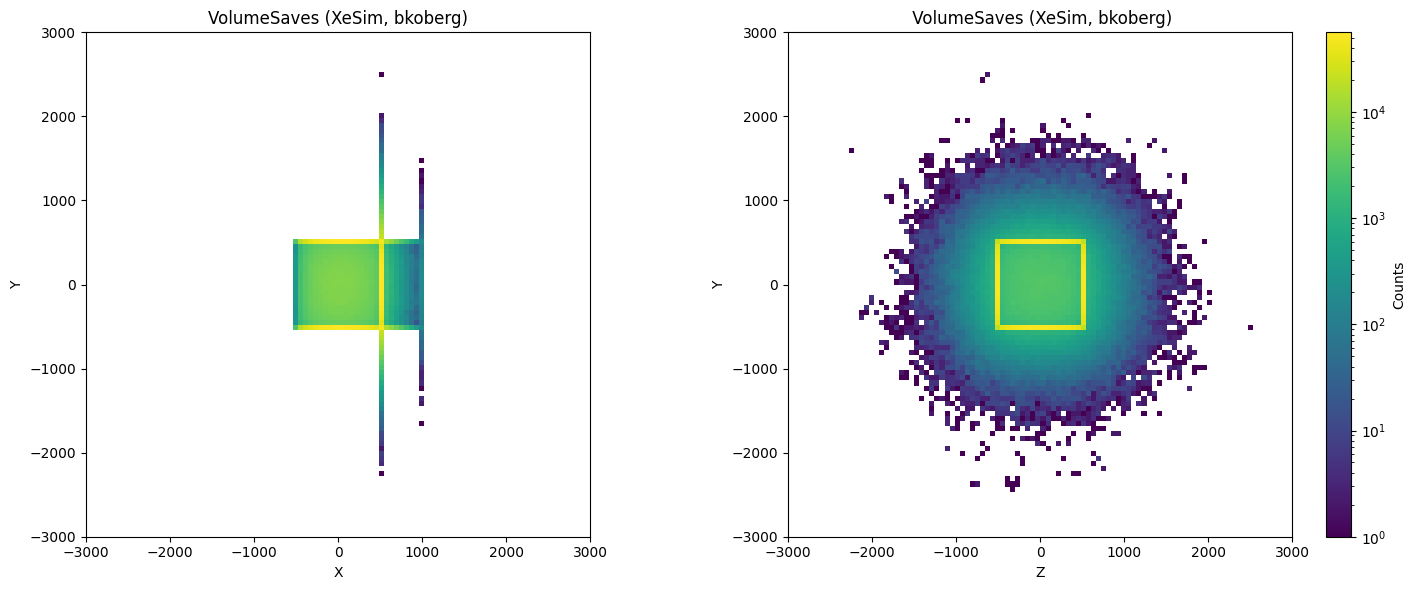

In [16]:
grid = False



for i,coord in enumerate(coords):
    if i == 0:
        a='PrimaryNeutrons'
    elif i == 1:
        a='NeutronActivations'
    elif i == 2:
        a='VolumeSaves'

    x_range, y_range, z_range = ranges[i]
    x_bins, y_bins, z_bins = bins_all[i]

    xy_proj = h3d_computed[i][:,:,sum].view()
    zy_proj = h3d_computed[i][sum,:,:].view()
    max_val = max(xy_proj.max(), zy_proj.max())

    fig ,ax = plt.subplots(nrows = 1, ncols = 2, figsize=(15, 6))

    #aspect = 'auto'

    norm = mpl.colors.LogNorm(vmin=1, vmax=max_val) 
    #norm = mpl.colors.Normalize(vmin=1, vmax=max_val*0.1)  # Use Normalize for linear scaling
    aspect = 'equal'

    ax[0].imshow(
        xy_proj.T,  
        extent=(x_range[0], x_range[1], y_range[0], y_range[1]),
        origin='lower',
        aspect=aspect,
        norm=norm
    )
    ax[0].set_xlabel('X')
    ax[0].set_ylabel('Y')
    ax[0].set_title(f'{a} ({path_length}, {path_Material})')



    # XZ-Projektion (Summe über y)
    ax[1].imshow(
        zy_proj.view().T,
        extent=(x_range[0], x_range[1], z_range[0], z_range[1]),
        origin='lower',
        aspect=aspect,
        norm=norm
    )
    ax[1].set_xlabel('Z')
    ax[1].set_ylabel('Y')
    ax[1].set_title(f' {a} ({path_length}, {path_Material})')

    if grid:
        ax[0].minorticks_on()
        ax[0].grid(which='major', linestyle='-', linewidth=0.7, color='gray')
        ax[0].grid(which='minor', linestyle=':', linewidth=0.4, color='lightgray')
        ax[1].minorticks_on()
        ax[1].grid(which='major', linestyle='-', linewidth=0.7, color='gray')
        ax[1].grid(which='minor', linestyle=':', linewidth=0.4, color='lightgray')

    fig.colorbar(ax[1].images[0], ax=ax[1], label='Counts')
    plt.tight_layout()

    plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/Potions_{a}.pdf" )
    plt.show()

### 3D

In [ ]:
uprooti = uproot_files  # Limit to first 10 files for testing

da_positions = uproot.dask(uprooti, filter_name=['xp_pri', 'yp_pri', 'zp_pri','type_pri_id', 'vol_pri','NAct_volume', 'NAct_x', 'NAct_y', 'NAct_z','Save_x', 'Save_y', 'Save_z', 'Save_volume', 'Save_desc'], allow_missing=True, step_size="8GB")
da_positions['type_pri_id'] = ak.flatten(da_positions['type_pri_id'])
da_positions = da_positions[da_positions['type_pri_id'] == 2112]

df_pri = da.to_dataframe(da_positions[['xp_pri', 'yp_pri', 'zp_pri']])
df_NAct = da.to_dataframe(da_positions[[ 'NAct_x', 'NAct_y', 'NAct_z', 'NAct_volume']])
df_Save = da.to_dataframe(da_positions[['Save_x', 'Save_y', 'Save_z', 'Save_volume', 'Save_desc']])


In [ ]:
with ProgressBar():
     df_pri = df_pri.compute()
     df_NAct = df_NAct.compute()
     df_Save = df_Save.compute()

In [ ]:
frac_pri = 0.001
frac_NAct = 0.001
frac_Save = 0.02

df_pri_sample = df_pri.sample(frac=frac_pri, random_state=42)
df_NAct_sample = df_NAct.sample(frac=frac_NAct, random_state=42)
df_Save_sample = df_Save.sample(frac=frac_Save, random_state=42)

In [ ]:
k = 2
if(k == 0):
    x = df_pri_sample['xp_pri']
    y = df_pri_sample['yp_pri']
    z = df_pri_sample['zp_pri']
elif(k == 1):
    x = df_NAct_sample['NAct_x']
    y = df_NAct_sample['NAct_y']
    z = df_NAct_sample['NAct_z']
    # Kategorien und gewünschte Farben zuweisen
    labels = pd.Categorical(df_NAct_sample['NAct_volume']).categories
    color_col = pd.Categorical(df_NAct_sample['NAct_volume']).codes

    # Beispiel: Farben zuweisen (Reihenfolge wie in labels)
    custom_colors = []
    for label in labels:
        if (label == "RockSpawnPhysicalVolume") or (label == "ConcreteSpawnPhysicalVolume"):
            custom_colors.append("green")
        elif label == "ConcretePhysicalVolume":
            custom_colors.append("grey")
        elif label == "RockPhysicalVolume":
            custom_colors.append("black")

    labels_colors = list(zip(labels, custom_colors))
    labels_colors_sorted = sorted(labels_colors, key=lambda x: x[1])  # sortiere nach Farbe (alphabetisch)

    labels_sorted = [lc[0] for lc in labels_colors_sorted]
    colors_sorted = [lc[1] for lc in labels_colors_sorted]

    # Mapping von altem code_col zu neuem Index nach Farbsortierung
    label_to_sorted_idx = {label: i for i, label in enumerate(labels_sorted)}
    color_col_sorted = [label_to_sorted_idx[label] for label in pd.Categorical(df_NAct_sample['NAct_volume']).categories]
    color_col = pd.Categorical(df_NAct_sample['NAct_volume']).codes
    color_col = [label_to_sorted_idx[labels[code]] for code in color_col]
elif(k == 2):
    x = df_Save_sample['Save_x']
    y = df_Save_sample['Save_y']
    z = df_Save_sample['Save_z']
    # Kategorien und gewünschte Farben zuweisen
    labels = pd.Categorical(df_Save_sample['Save_desc']).categories
    color_col = pd.Categorical(df_Save_sample['Save_desc']).codes

    # Beispiel: Farben zuweisen (Reihenfolge wie in labels)
    # Use valid hex codes for colors
    custom_colors = []
    for label in labels:
        if (label == "RockSpawnPhysicalVolume") :
            custom_colors.append("#5d4037")      # dark brown
        elif (label == "ConcreteSpawnPhysicalVolume") :
            custom_colors.append("#616161")      # dark grey
        elif label == "ConcretePhysicalVolume":
            custom_colors.append("#bdbdbd")      # light grey
        elif label == "RockPhysicalVolume":
            custom_colors.append("#a1887f")      # light brown
        elif label == "CountPhysicalVolume":
            custom_colors.append("#ff9800")      # orange

    labels_colors = list(zip(labels, custom_colors))
    labels_colors_sorted = sorted(labels_colors, key=lambda x: x[1])  # sortiere nach Farbe (alphabetisch)

    labels_sorted = [lc[0] for lc in labels_colors_sorted]
    colors_sorted = [lc[1] for lc in labels_colors_sorted]

    # Mapping von altem code_col zu neuem Index nach Farbsortierung
    label_to_sorted_idx = {label: i for i, label in enumerate(labels_sorted)}
    color_col_sorted = [label_to_sorted_idx[label] for label in pd.Categorical(df_Save_sample['Save_desc']).categories]
    color_col = pd.Categorical(df_Save_sample['Save_desc']).codes
    color_col = [label_to_sorted_idx[labels[code]] for code in color_col]


if k == 1 and df_NAct_sample.empty:
    print("No data to plot for Neutron Activations (df_NAct_sample is empty).")
else:
    fig = go.Figure(data=go.Scatter3d(
        x=x,
        y=y,
        z=z,
        mode='markers',
        marker=dict(
        size=2,
        color=color_col,  # immer color_col übergeben!
        colorscale=([[i/(len(colors_sorted)-1), c] for i, c in enumerate(colors_sorted)] if len(colors_sorted) > 0 else None),
        colorbar=(dict(
            title='Save_desc',
            tickvals=list(range(len(labels_sorted))),
            ticktext=labels_sorted
        ) if len(labels_sorted) > 0 else None)
    )
    ))
    fig.update_layout(
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y',
            zaxis_title='Z'
        ),
        width=1000,
        height=800
    )
    fig.show()

## Energy Distributions trend

In [8]:
da_vol = uproot.dask(uproot_files, filter_name=['eventid','e_pri', 'type_pri_id','Save_desc', 'Save_e', 'Save_volume', 'Save_trackid','NAct_process_name', 'NAct_trackid', 'NAct_volume'], allow_missing=True, step_size="8GB")
da_vol['type_pri_id'] = ak.flatten(da_vol['type_pri_id'])

df_pri = da.to_dataframe(da_vol[['e_pri','type_pri_id']])
df_pri = df_pri[df_pri['type_pri_id'] == 2112]
df = da.to_dataframe(da_vol[['eventid','Save_desc', 'Save_e', 'Save_volume', 'Save_trackid']])

df_NAct = da.to_dataframe(da_vol[['eventid','NAct_process_name', 'NAct_trackid', 'NAct_volume']])

In [9]:
labels = ['e_pri','Rock (not Spawn)', 'Concrete', 'Detector']

#df = df[df['Save_trackid'] < 5]

arrays = [df_pri[['e_pri']]]
arrays += [df[((df['Save_desc'] == "RockPhysicalVolume") | (df['Save_desc'] == "ConcretePhysicalVolume")) & (df['Save_volume'] == 'RockSpawnPhysicalVolume')]['Save_e']]
arrays += [df[df['Save_desc'].isin(["ConcretePhysicalVolume", "ConcreteSpawnPhysicalVolume"])]['Save_e']]
arrays += [df[df['Save_desc'] == "CountPhysicalVolume"]['Save_e']]

In [10]:
hist_tasks = []
bins = []

for i in range(len(arrays)):
    hist_task, bin_edges = dh.histogram(arrays[i], bins=100, range=(0,15000))
    hist_tasks.append(hist_task)
    bins.append(bin_edges)


In [11]:
with ProgressBar():
    hist_vals_list = [a.compute() for a in hist_tasks]
    bin_edges_list = [b.compute() for b in bins]


[########################################] | 100% Completed | 302.68 ms
[########################################] | 100% Completed | 5.91 sms
[########################################] | 100% Completed | 5.67 sms
[########################################] | 100% Completed | 5.82 sms
[########################################] | 100% Completed | 100.93 ms
[########################################] | 100% Completed | 100.71 ms
[########################################] | 100% Completed | 100.72 ms
[########################################] | 100% Completed | 100.85 ms


1
0
2
3


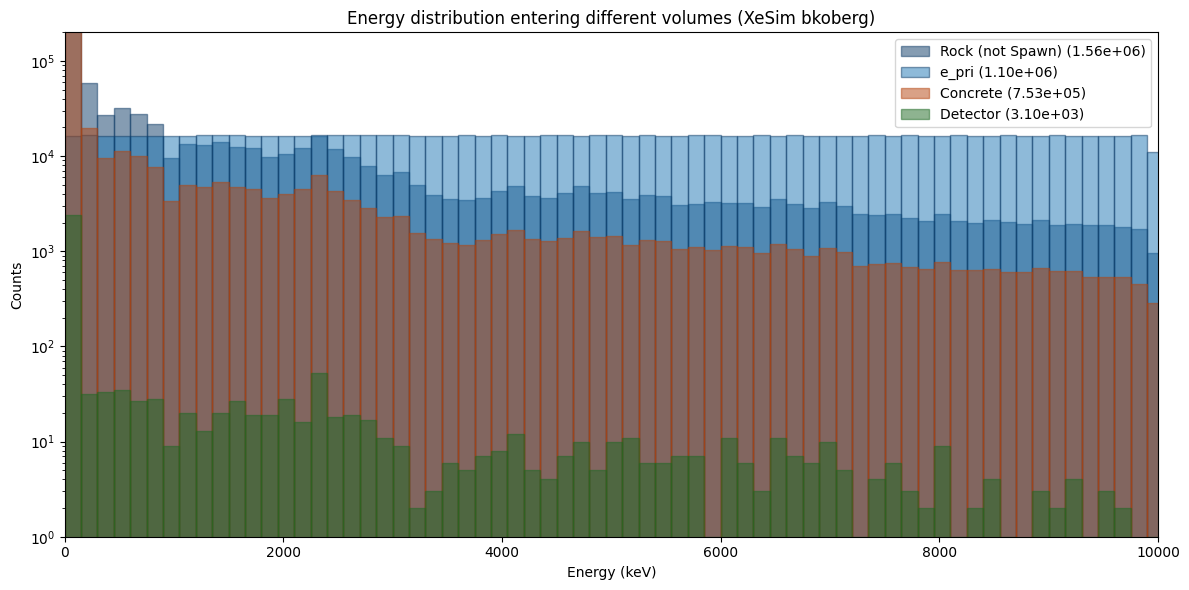

In [12]:
plt.figure(figsize=(12, 6))

all_indices = [
    i for i in range(len(hist_vals_list))
]

# Nach Länge sortieren (absteigend)
# Sortiere die Indizes nach der Summe der Histogrammwerte
all_indices_sorted = sorted(
    all_indices,
    key=lambda i: sum(hist_vals_list[i]),
    reverse=True
)



for i in all_indices_sorted:
    print(i)
    # Use colors_Volumes and volumes only for indices 1,2,3 (since volumes has length 3)
    if i > 0 and (i-1) < len(volumes):
        bar_color = colors_Volumes[volumes[i-1]]
        bar_edge_color = colors_edges[volumes[i-1]]
    else:
        bar_color = colors[0]
        bar_edge_color = edge_colors[0] if isinstance(edge_colors, list) else colors[0]
    # Use bar_edge_color safely
    plt.bar(bin_edges_list[i][:-1], hist_vals_list[i],
            width=bin_edges_list[i][1] - bin_edges_list[i][0],
            align='edge',
            color=bar_color, edgecolor=bar_edge_color,
            label=f'{labels[i]} ({sum(hist_vals_list[i]):.2e})',
            alpha=0.5)

plt.xlim(0, 10000)

plt.yscale('log')
plt.ylim(1,2e5)

plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.title('Energy distribution entering different volumes ({} {})'.format(path_length, path_Material))
plt.tight_layout()
plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/EnergyDistributions_Volumes.pdf" )
plt.show()

## NC Energydependent


In [ ]:
da_energy = uproot.dask(uproot_files, filter_name=['e_pri','type_pri_id','NAct_particle_id', 'NAct_process_ID', 'NAct_volume'], allow_missing=True)#, step_size="180MB")
da_energy['type_pri_id'] = ak.flatten(da_energy['type_pri_id'])

da_energy = da_energy[da_energy['type_pri_id'] == 2112]

In [ ]:
df_pri = da.to_dataframe(da_energy[['e_pri']])
df = da.to_dataframe(da_energy[['e_pri', 'NAct_process_ID', 'NAct_volume']])

### In Liquid Xenon

In [ ]:
only_LXe_volume = df[df['NAct_volume'] == "LXe"]
only_nCapture = only_LXe_volume[only_LXe_volume['NAct_process_ID'] == 131]  #nCapture
data = only_nCapture[['e_pri']]

In [ ]:
df_pri = df_pri.repartition(npartitions=100)
data = data.repartition(npartitions=100)

In [ ]:
bins = 101
ranges = (0,10000)

hist_pri = dh.histogram(df_pri['e_pri'], bins=bins, range=ranges)
hist = dh.histogram(data['e_pri'], bins=bins, range=ranges)

In [ ]:
with ProgressBar():
    #hist_pri_vals = hist_pri[0].compute()
    #hist_pri_edges = hist_pri[1].compute()
    hist_vals = hist[0].compute(num_workers=3)
    #hist_edges = hist[1].compute()

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(
    hist_pri_edges[:-1], hist_pri_vals,
    width=np.diff(hist_edges),
    align='edge',
    color=colors[0], alpha=0.2,
    edgecolor=edge_colors[1], linewidth=0.3,
    label=f'Neutron Captures ({hist_pri_vals.sum():.2e}) in LXe'
)

plt.bar(
    hist_edges[:-1], hist_vals,
    width=np.diff(hist_edges),
    align='edge',
    color=colors[1], alpha=1,
    edgecolor=edge_colors[1], linewidth=0.3,
    label=f'Neutron Captures ({hist_vals.sum():.2e}) in LXe'
)
plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0.1, 3e5)
plt.xlim(0, 10000)
plt.title(f'Primary energy of Neutron Captures in LXe  ({path_length},{path_Material})')
plt.tight_layout()
plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/EnergyNC_LXe.pdf")
plt.show()

### In Absorber

In [ ]:
only_Absorber_volume = df[df['NAct_volume'] == "Absorber"]
only_nCapture = only_Absorber_volume[only_Absorber_volume['NAct_process_ID'] == 131]  #nCapture
data = only_nCapture[['e_pri']]

In [ ]:
bins = 101
ranges = (0,10000)

hist_pri = dh.histogram(df_pri['e_pri'], bins=bins, range=ranges)
hist = dh.histogram(data['e_pri'], bins=bins, range=ranges)

In [ ]:
with ProgressBar():
    hist_pri_vals = hist_pri[0].compute()
    hist_pri_edges = hist_pri[1].compute()
    hist_vals = hist[0].compute()
    hist_edges = hist[1].compute()

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(
    hist_pri_edges[:-1], hist_pri_vals,
    width=np.diff(hist_edges),
    align='edge',
    color=colors[0], alpha=0.2,
    edgecolor=edge_colors[1], linewidth=0.3,
    label=f'Neutron Captures ({hist_pri_vals.sum():.2e}) in LXe'
)

plt.bar(
    hist_edges[:-1], hist_vals,
    width=np.diff(hist_edges),
    align='edge',
    color=colors[1], alpha=1,
    edgecolor=edge_colors[1], linewidth=0.3,
    label=f'Neutron Captures ({hist_vals.sum():.2e}) in LXe'
)
plt.xlabel('Energy (keV)')
plt.ylabel('Counts')
plt.yscale('log')
plt.ylim(0.1, 3e5)
plt.xlim(0, 10000)
plt.ylim(0.1, 2e5) 
plt.title(f'Energy dependence of Neutron Captures in the Absorber ({path_length},{path_Material})')
plt.tight_layout()
plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/EnergyNC_Absorber.pdf" )
plt.show()

## Processes

In [ ]:
da_processes = uproot.dask(uproot_files, filter_name=['e_pri','NAct_particle_id', 'NAct_process_ID', 'NAct_volume'], allow_missing=True, step_size="8GB")

df = da.to_dataframe(da_processes)

### Xenon Volume

In [ ]:
only_LXe_volume = df[df['NAct_volume'] == "LXe"]

only_nCapture = only_LXe_volume[only_LXe_volume['NAct_process_ID'] == 131]  #nCapture

only_LXe_volume = only_nCapture[['NAct_particle_id','NAct_process_ID']]

In [ ]:
with ProgressBar():
    grouped_data = only_LXe_volume.groupby(['NAct_particle_id','NAct_process_ID']).size().compute()


grouped_data.index = grouped_data.index.set_levels(
    grouped_data.index.levels[0].map(lambda x: get_particle_name(x)), level = 0
)
grouped_data.index = grouped_data.index.set_levels(
    grouped_data.index.levels[1].map(lambda x: get_process_name(x)), level = 1
)


In [ ]:
_data = grouped_data#[grouped_data.values > 40]

_particles = np.unique(_data.index.get_level_values(0))
_processes = np.unique(_data.index.get_level_values(1))

def get_value(data,pr,p):
    try:
        return data[p,pr]
    except:
        return 0
    
_counts = {pr: [get_value(_data,pr,p) for p in _particles] for pr in _processes} 
_processes_sorted = sorted(_processes, key=lambda pr: sum(_counts[pr]))
color = {pr: colors[idx % len(colors)] for idx, pr in enumerate(_processes_sorted)}


plt.figure(dpi=150, figsize =(15,8))

x = np.arange(len(_particles))
bottom = np.zeros(len(_particles))
for idx, pr in enumerate(_processes_sorted):
    plt.bar(x, _counts[pr], 0.8, label=pr, bottom=bottom, color=colors_process[pr])
    bottom += np.array(_counts[pr])

ax = plt.gca()
ax.set_xticks(x)
ax.set_xticklabels(_particles, rotation=90, ha='center')

plt.xlabel("Particle name")
plt.ylabel("Counts")
plt.title("Neutron activation products in the LXe ({} {})".format(path_length, path_Material))
plt.yscale("log")
plt.ylim(0.1,1e6)

plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/Processes_LXe.pdf" )
plt.tight_layout()
plt.grid()

plt.show()




### Absorber Volume

In [ ]:
only_Absorber_volume = df[df['NAct_volume'] == "Absorber"]

only_PartProcess = only_Absorber_volume[['NAct_particle_id','NAct_process_ID']]

In [ ]:
with ProgressBar():
    grouped_data = only_PartProcess.groupby(['NAct_particle_id','NAct_process_ID']).size().compute()


grouped_data.index = grouped_data.index.set_levels(
    grouped_data.index.levels[0].map(lambda x: get_particle_name(x)), level = 0
)
grouped_data.index = grouped_data.index.set_levels(
    grouped_data.index.levels[1].map(lambda x: get_process_name(x)), level = 1
)


In [ ]:
_data = grouped_data#[grouped_data.values > 40]
#_data = grouped_data

_particles = np.unique(_data.index.get_level_values(0))
_processes = np.unique(_data.index.get_level_values(1))



def get_value(data,pr,p):
    try:
        return data[p,pr]
    except:
        return 0

_counts = {pr: [get_value(_data,pr,p) for p in _particles] for pr in _processes} 
_processes_sorted = sorted(_processes, key=lambda pr: sum(_counts[pr]))

plt.figure(dpi=150, figsize =(15,8))

x = np.arange(len(_particles))
bottom = np.zeros(len(_particles))
for idx, pr in enumerate(_processes_sorted):
    print(idx)
    plt.bar(x, _counts[pr], 0.8, label=pr, bottom=bottom, color=colors_process[pr])
    bottom += np.array(_counts[pr])

ax = plt.gca()
ax.set_xticks(x)
ax.set_xticklabels(_particles, rotation=90, ha='center')

plt.xlabel("Particle name")
plt.ylabel("Counts")
plt.title("Neutron activation products in the Absorber ({} {})".format(path_length, path_Material))
plt.yscale("log")
plt.ylim(0.1,1e7)

plt.legend()
plt.savefig(f"/home/b/bkoberg/AGW_LowRad/home/bkoberg/XeSim/notebooks/Pictures/{path_Version}/{path_Material}/{path_length}/Processes_Absorber.pdf" )
plt.tight_layout()
plt.show()



In [ ]:
plt.figure(dpi=150, figsize=(15, 8))

x = np.arange(len(_particles))
bar_width = 0.8 / len(_processes)  # Balken schmaler machen, damit sie nebeneinander passen

for i, pr in enumerate(_processes):
    plt.bar(x + i * bar_width, _counts[pr], bar_width, label=pr)

ax = plt.gca()
ax.set_xticks(x + bar_width * (len(_processes)-1)/2)
ax.set_xticklabels(_particles, rotation=90, ha='center')

plt.xlabel("Particle name")
plt.ylabel("Counts")
plt.title("Neutron activation products in the Absorber")
plt.yscale("log")
plt.ylim(0.1, 1e7)
plt.legend()
plt.tight_layout()
plt.show()